# This notebook reproduces following figures: Fig. 3, Fig. S3.

Following network files were used to simulate the networks:
- nw_iall_ei_assembly.py
- nw_ie_ei_assembly.py

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

## Fig 3: Co-active I-to-I plasticity carves the I-to-E connectivity, making EI assemblies distinguishable.

IE synapses in window: 15010
II synapses in window: 5036


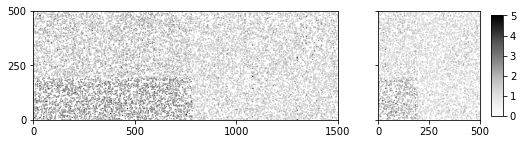

In [18]:
d = np.load("data/fig3/final_weights_and_connectivity_iall_400sec.npz")

total_exc = int(d["total_exc"]) if "total_exc" in d else 8000

pre_IE = d["pre_IE"]
post_IE = d["post_IE"]
w_IE = d["w_IE"]

pre_IE_local = pre_IE - total_exc
post_IE_local = post_IE

IE_pre_lo, IE_pre_hi = 0, 500
IE_post_lo, IE_post_hi = 0, 1500

mask_IE = (
    (pre_IE_local >= IE_pre_lo) & (pre_IE_local <= IE_pre_hi) &
    (post_IE_local >= IE_post_lo) & (post_IE_local <= IE_post_hi)
)

pre_IE_plot = pre_IE_local[mask_IE]
post_IE_plot = post_IE_local[mask_IE]
w_IE_plot = w_IE[mask_IE]

n_IE = w_IE_plot.size

print(f"IE synapses in window: {n_IE}")

pre_II = d["pre_II"]
post_II = d["post_II"]
w_II = d["w_II"]

pre_II_local = pre_II - total_exc
post_II_local = post_II - total_exc

II_pre_lo, II_pre_hi = 0, 500
II_post_lo, II_post_hi = 0, 500

mask_II = (
    (pre_II_local >= II_pre_lo) & (pre_II_local <= II_pre_hi) &
    (post_II_local >= II_post_lo) & (post_II_local <= II_post_hi)
)

pre_II_plot = pre_II_local[mask_II]
post_II_plot = post_II_local[mask_II]
w_II_plot = w_II[mask_II]

n_II = w_II_plot.size

print(f"II synapses in window: {n_II}")

norm = mpl.colors.Normalize(vmin=0, vmax=5)
cmap = "Greys"

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 2),
    sharey=True,
    gridspec_kw={"width_ratios": [3, 1]}
)

ax1.scatter(
    post_IE_plot, pre_IE_plot,
    c=w_IE_plot,
    s=2,
    cmap=cmap,
    norm=norm,
    edgecolors="none"
)
ax1.set_xlim(IE_post_lo, IE_post_hi)
ax1.set_ylim(IE_pre_lo, IE_pre_hi)
ax1.set_xticks([0, 500, 1000, 1500])
ax1.set_yticks([0, 250, 500])

ax2.scatter(
    post_II_plot, pre_II_plot,
    c=w_II_plot,
    s=2,
    cmap=cmap,
    norm=norm,
    edgecolors="none"
)
ax2.set_xlim(II_post_lo, II_post_hi)
ax2.set_xticks([0, 250, 500])

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks([0, 1, 2, 3, 4, 5])
plt.show()


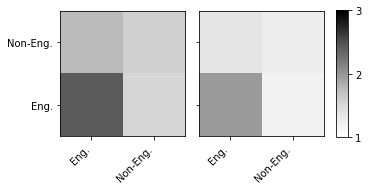

In [13]:
d = np.load("data/fig3/final_weights_and_connectivity_iall_400sec.npz")
total_exc = int(d["total_exc"]) if "total_exc" in d else 8000
total_neurons = int(d["total_neurons"]) if "total_neurons" in d else 10000
total_inh = total_neurons - total_exc

E_ENG_N = 784
I_ENG_N = 196

E_eng = np.arange(0, E_ENG_N)
E_non = np.arange(E_ENG_N, total_exc)

I_eng_local = np.arange(0, I_ENG_N)
I_non_local = np.arange(I_ENG_N, total_inh)

pre_IE_g = d["pre_IE"]
post_IE = d["post_IE"]
w_IE = d["w_IE"]

pre_II_g = d["pre_II"]
post_II_g = d["post_II"]
w_II = d["w_II"]

pre_IE = pre_IE_g - total_exc
pre_II = pre_II_g - total_exc
post_II = post_II_g - total_exc

def mean_or_nan(arr):
    return np.nan if arr.size == 0 else float(np.mean(arr))

pre_Ieng = np.isin(pre_IE, I_eng_local)
pre_Inon = np.isin(pre_IE, I_non_local)
post_Eeng = np.isin(post_IE, E_eng)
post_Enon = np.isin(post_IE, E_non)

M_IE = np.array([
    [mean_or_nan(w_IE[pre_Ieng & post_Eeng]), mean_or_nan(w_IE[pre_Ieng & post_Enon])],
    [mean_or_nan(w_IE[pre_Inon & post_Eeng]), mean_or_nan(w_IE[pre_Inon & post_Enon])]
])

pre_Ieng2 = np.isin(pre_II, I_eng_local)
pre_Inon2 = np.isin(pre_II, I_non_local)
post_Ieng = np.isin(post_II, I_eng_local)
post_Inon = np.isin(post_II, I_non_local)

M_II = np.array([
    [mean_or_nan(w_II[pre_Ieng2 & post_Ieng]), mean_or_nan(w_II[pre_Ieng2 & post_Inon])],
    [mean_or_nan(w_II[pre_Inon2 & post_Ieng]), mean_or_nan(w_II[pre_Inon2 & post_Inon])]
])

M_IE = M_IE[::-1, :]
M_II = M_II[::-1, :]

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), constrained_layout=True)

vmin = 1
vmax = 3

im0 = axes[0].imshow(
    M_IE, origin="upper", cmap="Greys",
    aspect="equal", vmin=vmin, vmax=vmax
)
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Eng.", "Non-Eng."], rotation=45, ha="right")
axes[0].set_yticklabels(["Non-Eng.", "Eng."])

im1 = axes[1].imshow(
    M_II, origin="upper", cmap="Greys",
    aspect="equal", vmin=vmin, vmax=vmax
)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Eng.", "Non-Eng."], rotation=45, ha="right")
axes[1].set_yticklabels([])

cbar = fig.colorbar(im1, ax=axes, shrink=0.9)
cbar.set_ticks([1, 2, 3])

plt.show()

IE engram: 3046 IE non-engram: 316477
II engram: 756 II non-engram: 79352


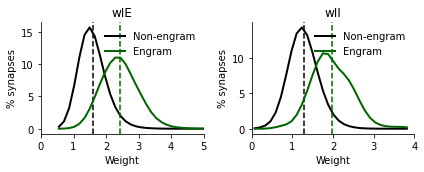

In [14]:
d = np.load("data/fig3/final_weights_and_connectivity_iall_400sec.npz")
 
total_exc = int(d["total_exc"])

pre_IE, post_IE, w_IE = d["pre_IE"], d["post_IE"], d["w_IE"]
pre_II, post_II, w_II = d["pre_II"], d["post_II"], d["w_II"]

E_eng = np.arange(0, 784)
I_eng = total_exc + np.arange(0, 196)

E_eng_set = set(E_eng.tolist())
I_eng_set = set(I_eng.tolist())

mask_IE_eng = np.isin(pre_IE, I_eng) & np.isin(post_IE, E_eng)
wIE_eng = w_IE[mask_IE_eng]
wIE_non = w_IE[~mask_IE_eng]

mask_II_eng = np.isin(pre_II, I_eng) & np.isin(post_II, I_eng)
wII_eng = w_II[mask_II_eng]
wII_non = w_II[~mask_II_eng]

print("IE engram:", wIE_eng.size, "IE non-engram:", wIE_non.size)
print("II engram:", wII_eng.size, "II non-engram:", wII_non.size)

def gaussian_kernel1d(sigma_bins, radius=4):
    r = int(np.ceil(radius * sigma_bins))
    x = np.arange(-r, r + 1)
    k = np.exp(-(x**2) / (2 * sigma_bins**2))
    k /= k.sum()
    return k

def smooth_curve(y, sigma_bins=1.2):
    return np.convolve(y, gaussian_kernel1d(sigma_bins), mode="same")

def smooth_percent_hist(ax, x, bins, color, alpha=1.0, label=None, sigma_bins=1.2):
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan

    counts, edges = np.histogram(x, bins=bins, density=False)
    centers = 0.5 * (edges[:-1] + edges[1:])

    y = counts * 100.0 / x.size
    y_s = smooth_curve(y, sigma_bins=sigma_bins)

    ax.plot(centers, y_s, color=color, lw=2, alpha=alpha, label=label)

    mu = x.mean()
    ax.axvline(mu, color=color, ls="--", lw=1.5, alpha=alpha)

    ax.set_ylabel("% synapses")
    ax.set_xlabel("Weight")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return mu

def plot_engram_vs_non(ax, eng, non, title, bins=40, sigma_bins=1.2, xlim=None):
    eng = eng[np.isfinite(eng)]
    non = non[np.isfinite(non)]

    all_vals = np.concatenate([eng, non]) if (eng.size and non.size) else (eng if eng.size else non)
    if all_vals.size == 0:
        ax.set_title(title)
        return

    edges = np.histogram_bin_edges(all_vals, bins=bins)

    smooth_percent_hist(ax, non, bins=edges, color="black", alpha=1.0, label="Non-engram", sigma_bins=sigma_bins)
    smooth_percent_hist(ax, eng, bins=edges, color="darkgreen", alpha=1.0, label="Engram", sigma_bins=sigma_bins)

    ax.set_title(title)
    ax.legend(frameon=False)

    if xlim is not None:
        ax.set_xlim(*xlim)

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=False)

plot_engram_vs_non(axes[0], wIE_eng, wIE_non, "wIE", bins=30, sigma_bins=1.2, xlim=(0, 5))
plot_engram_vs_non(axes[1], wII_eng, wII_non, "wII", bins=30, sigma_bins=1.2, xlim=(0, 4))

plt.tight_layout()
plt.show()

IE synapses in window: 14979
II synapses in window: 5109


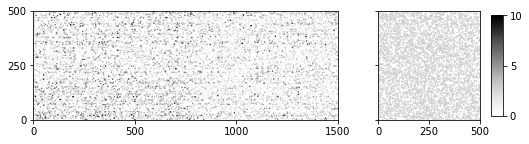

In [15]:
d = np.load("data/fig3/final_weights_and_connectivity_ie_400sec.npz")

total_exc = int(d["total_exc"]) if "total_exc" in d else 8000

pre_IE = d["pre_IE"]
post_IE = d["post_IE"]
w_IE = d["w_IE"]

pre_IE_local = pre_IE - total_exc
post_IE_local = post_IE

IE_pre_lo, IE_pre_hi = 0, 500
IE_post_lo, IE_post_hi = 0, 1500

mask_IE = (
    (pre_IE_local >= IE_pre_lo) & (pre_IE_local <= IE_pre_hi) &
    (post_IE_local >= IE_post_lo) & (post_IE_local <= IE_post_hi)
)

pre_IE_plot = pre_IE_local[mask_IE]
post_IE_plot = post_IE_local[mask_IE]
w_IE_plot = w_IE[mask_IE]

n_IE = w_IE_plot.size

print(f"IE synapses in window: {n_IE}")

pre_II = d["pre_II"]
post_II = d["post_II"]
w_II = d["w_II"]

pre_II_local = pre_II - total_exc
post_II_local = post_II - total_exc

II_pre_lo, II_pre_hi = 0, 500
II_post_lo, II_post_hi = 0, 500

mask_II = (
    (pre_II_local >= II_pre_lo) & (pre_II_local <= II_pre_hi) &
    (post_II_local >= II_post_lo) & (post_II_local <= II_post_hi)
)

pre_II_plot = pre_II_local[mask_II]
post_II_plot = post_II_local[mask_II]
w_II_plot = w_II[mask_II]

n_II = w_II_plot.size

print(f"II synapses in window: {n_II}")

norm = mpl.colors.Normalize(vmin=0, vmax=10)
cmap = "Greys"

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 2),
    sharey=True,
    gridspec_kw={"width_ratios": [3, 1]}
)

ax1.scatter(
    post_IE_plot, pre_IE_plot,
    c=w_IE_plot,
    s=2,
    cmap=cmap,
    norm=norm,
    edgecolors="none"
)
ax1.set_xlim(IE_post_lo, IE_post_hi)
ax1.set_ylim(IE_pre_lo, IE_pre_hi)
ax1.set_xticks([0, 500, 1000, 1500])
ax1.set_yticks([0, 250, 500])

ax2.scatter(
    post_II_plot, pre_II_plot,
    c=w_II_plot*1e9,
    s=2,
    cmap=cmap,
    norm=norm,
    edgecolors="none"
)
ax2.set_xlim(II_post_lo, II_post_hi)
ax2.set_xticks([0, 250, 500])

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks([0, 5, 10])
plt.show()


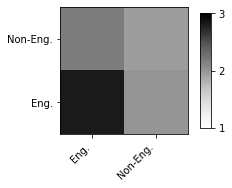

In [16]:
d = np.load("data/fig3/final_weights_and_connectivity_ie_400sec.npz")
total_exc = int(d["total_exc"]) if "total_exc" in d else 8000
total_neurons = int(d["total_neurons"]) if "total_neurons" in d else 10000
total_inh = total_neurons - total_exc

E_ENG_N = 784
I_ENG_N = 196

E_eng = np.arange(0, E_ENG_N)
E_non = np.arange(E_ENG_N, total_exc)

I_eng_local = np.arange(0, I_ENG_N)
I_non_local = np.arange(I_ENG_N, total_inh)

pre_IE_g = d["pre_IE"]
post_IE = d["post_IE"]
w_IE = d["w_IE"]

pre_IE = pre_IE_g - total_exc

def mean_or_nan(arr):
    return np.nan if arr.size == 0 else float(np.mean(arr))

pre_Ieng = np.isin(pre_IE, I_eng_local)
pre_Inon = np.isin(pre_IE, I_non_local)
post_Eeng = np.isin(post_IE, E_eng)
post_Enon = np.isin(post_IE, E_non)

M_IE = np.array([
    [mean_or_nan(w_IE[pre_Ieng & post_Eeng]), mean_or_nan(w_IE[pre_Ieng & post_Enon])],
    [mean_or_nan(w_IE[pre_Inon & post_Eeng]), mean_or_nan(w_IE[pre_Inon & post_Enon])]
])

M_IE = M_IE[::-1, :]

fig, axes = plt.subplots(1, 1, figsize=(5, 2.5), constrained_layout=True)

vmin = 1
vmax = 3

im0 = axes.imshow(
    M_IE, origin="upper", cmap="Greys",
    aspect="equal", vmin=vmin, vmax=vmax
)
axes.set_xticks([0, 1])
axes.set_yticks([0, 1])
axes.set_xticklabels(["Eng.", "Non-Eng."], rotation=45, ha="right")
axes.set_yticklabels(["Non-Eng.", "Eng."])

cbar = fig.colorbar(im0, ax=axes, shrink=0.9)
cbar.set_ticks([1, 2, 3])
plt.show()

IE engram: 3107 IE non-engram: 316407
II engram: 754 II non-engram: 79240


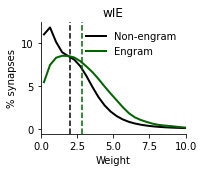

In [17]:
d = np.load("data/fig3/final_weights_and_connectivity_ie_400sec.npz")

total_exc = int(d["total_exc"])

pre_IE, post_IE, w_IE = d["pre_IE"], d["post_IE"], d["w_IE"]
pre_II, post_II, w_II = d["pre_II"], d["post_II"], d["w_II"]

E_eng = np.arange(0, 784)
I_eng = total_exc + np.arange(0, 196)

E_eng_set = set(E_eng.tolist())
I_eng_set = set(I_eng.tolist())

mask_IE_eng = np.isin(pre_IE, I_eng) & np.isin(post_IE, E_eng)
wIE_eng = w_IE[mask_IE_eng]
wIE_non = w_IE[~mask_IE_eng]

mask_II_eng = np.isin(pre_II, I_eng) & np.isin(post_II, I_eng)
wII_eng = w_II[mask_II_eng]
wII_non = w_II[~mask_II_eng]

print("IE engram:", wIE_eng.size, "IE non-engram:", wIE_non.size)
print("II engram:", wII_eng.size, "II non-engram:", wII_non.size)

def gaussian_kernel1d(sigma_bins, radius=4):
    r = int(np.ceil(radius * sigma_bins))
    x = np.arange(-r, r + 1)
    k = np.exp(-(x**2) / (2 * sigma_bins**2))
    k /= k.sum()
    return k

def smooth_curve(y, sigma_bins=1.2):
    return np.convolve(y, gaussian_kernel1d(sigma_bins), mode="same")

def smooth_percent_hist(ax, x, bins, color, alpha=1.0, label=None, sigma_bins=1.2):
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan

    counts, edges = np.histogram(x, bins=bins, density=False)
    centers = 0.5 * (edges[:-1] + edges[1:])

    y = counts * 100.0 / x.size
    y_s = smooth_curve(y, sigma_bins=sigma_bins)

    ax.plot(centers, y_s, color=color, lw=2, alpha=alpha, label=label)

    mu = x.mean()
    ax.axvline(mu, color=color, ls="--", lw=1.5, alpha=alpha)

    ax.set_ylabel("% synapses")
    ax.set_xlabel("Weight")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return mu

def plot_engram_vs_non(ax, eng, non, title, bins=40, sigma_bins=1.2, xlim=None):
    eng = eng[np.isfinite(eng)]
    non = non[np.isfinite(non)]

    all_vals = np.concatenate([eng, non]) if (eng.size and non.size) else (eng if eng.size else non)
    if all_vals.size == 0:
        ax.set_title(title)
        return

    edges = np.histogram_bin_edges(all_vals, bins=bins)

    smooth_percent_hist(ax, non, bins=edges, color="black", alpha=1.0, label="Non-engram", sigma_bins=sigma_bins)
    smooth_percent_hist(ax, eng, bins=edges, color="darkgreen", alpha=1.0, label="Engram", sigma_bins=sigma_bins)

    ax.set_title(title)
    ax.legend(frameon=False)

    if xlim is not None:
        ax.set_xlim(*xlim)

fig, axes = plt.subplots(1, 1, figsize=(3, 2.5), sharey=False)

plot_engram_vs_non(axes, wIE_eng, wIE_non, "wIE", bins=70, sigma_bins=1.2, xlim=(0, 10))

plt.tight_layout()
plt.show()

## Fig S3: Connectivity of the network with I-to-All plasticity without the excitatory-inhibitory assembly.

IE synapses in window: 15010
II synapses in window: 5036


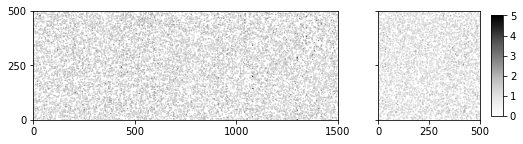

In [20]:
d = np.load("data/fig3/no_assembly_final_weights_and_connectivity_iall_400sec.npz")

total_exc = int(d["total_exc"]) if "total_exc" in d else 8000

pre_IE = d["pre_IE"]
post_IE = d["post_IE"]
w_IE = d["w_IE"]

pre_IE_local = pre_IE - total_exc
post_IE_local = post_IE

IE_pre_lo, IE_pre_hi = 0, 500
IE_post_lo, IE_post_hi = 0, 1500

mask_IE = (
    (pre_IE_local >= IE_pre_lo) & (pre_IE_local <= IE_pre_hi) &
    (post_IE_local >= IE_post_lo) & (post_IE_local <= IE_post_hi)
)

pre_IE_plot = pre_IE_local[mask_IE]
post_IE_plot = post_IE_local[mask_IE]
w_IE_plot = w_IE[mask_IE]

n_IE = w_IE_plot.size

print(f"IE synapses in window: {n_IE}")

pre_II = d["pre_II"]
post_II = d["post_II"]
w_II = d["w_II"]

pre_II_local = pre_II - total_exc
post_II_local = post_II - total_exc

II_pre_lo, II_pre_hi = 0, 500
II_post_lo, II_post_hi = 0, 500

mask_II = (
    (pre_II_local >= II_pre_lo) & (pre_II_local <= II_pre_hi) &
    (post_II_local >= II_post_lo) & (post_II_local <= II_post_hi)
)

pre_II_plot = pre_II_local[mask_II]
post_II_plot = post_II_local[mask_II]
w_II_plot = w_II[mask_II]

n_II = w_II_plot.size

print(f"II synapses in window: {n_II}")

norm = mpl.colors.Normalize(vmin=0, vmax=5)
cmap = "Greys"

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 2),
    sharey=True,
    gridspec_kw={"width_ratios": [3, 1]}
)

ax1.scatter(
    post_IE_plot, pre_IE_plot,
    c=w_IE_plot,
    s=2,
    cmap=cmap,
    norm=norm,
    edgecolors="none"
)
ax1.set_xlim(IE_post_lo, IE_post_hi)
ax1.set_ylim(IE_pre_lo, IE_pre_hi)
ax1.set_xticks([0, 500, 1000, 1500])
ax1.set_yticks([0, 250, 500])

ax2.scatter(
    post_II_plot, pre_II_plot,
    c=w_II_plot,
    s=2,
    cmap=cmap,
    norm=norm,
    edgecolors="none"
)
ax2.set_xlim(II_post_lo, II_post_hi)
ax2.set_xticks([0, 250, 500])

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks([0, 1, 2, 3, 4, 5])
plt.show()


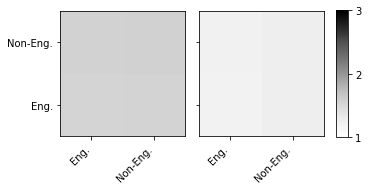

In [21]:
d = np.load("data/fig3/no_assembly_final_weights_and_connectivity_iall_400sec.npz")

total_exc = int(d["total_exc"]) if "total_exc" in d else 8000
total_neurons = int(d["total_neurons"]) if "total_neurons" in d else 10000
total_inh = total_neurons - total_exc

E_ENG_N = 784
I_ENG_N = 196

E_eng = np.arange(0, E_ENG_N)
E_non = np.arange(E_ENG_N, total_exc)

I_eng_local = np.arange(0, I_ENG_N)
I_non_local = np.arange(I_ENG_N, total_inh)

pre_IE_g = d["pre_IE"]
post_IE = d["post_IE"]
w_IE = d["w_IE"]

pre_II_g = d["pre_II"]
post_II_g = d["post_II"]
w_II = d["w_II"]

pre_IE = pre_IE_g - total_exc
pre_II = pre_II_g - total_exc
post_II = post_II_g - total_exc

def mean_or_nan(arr):
    return np.nan if arr.size == 0 else float(np.mean(arr))

pre_Ieng = np.isin(pre_IE, I_eng_local)
pre_Inon = np.isin(pre_IE, I_non_local)
post_Eeng = np.isin(post_IE, E_eng)
post_Enon = np.isin(post_IE, E_non)

M_IE = np.array([
    [mean_or_nan(w_IE[pre_Ieng & post_Eeng]), mean_or_nan(w_IE[pre_Ieng & post_Enon])],
    [mean_or_nan(w_IE[pre_Inon & post_Eeng]), mean_or_nan(w_IE[pre_Inon & post_Enon])]
])

pre_Ieng2 = np.isin(pre_II, I_eng_local)
pre_Inon2 = np.isin(pre_II, I_non_local)
post_Ieng = np.isin(post_II, I_eng_local)
post_Inon = np.isin(post_II, I_non_local)

M_II = np.array([
    [mean_or_nan(w_II[pre_Ieng2 & post_Ieng]), mean_or_nan(w_II[pre_Ieng2 & post_Inon])],
    [mean_or_nan(w_II[pre_Inon2 & post_Ieng]), mean_or_nan(w_II[pre_Inon2 & post_Inon])]
])

M_IE = M_IE[::-1, :]
M_II = M_II[::-1, :]

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), constrained_layout=True)

vmin = 1
vmax = 3

im0 = axes[0].imshow(
    M_IE, origin="upper", cmap="Greys",
    aspect="equal", vmin=vmin, vmax=vmax
)
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Eng.", "Non-Eng."], rotation=45, ha="right")
axes[0].set_yticklabels(["Non-Eng.", "Eng."])

im1 = axes[1].imshow(
    M_II, origin="upper", cmap="Greys",
    aspect="equal", vmin=vmin, vmax=vmax
)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Eng.", "Non-Eng."], rotation=45, ha="right")
axes[1].set_yticklabels([])

cbar = fig.colorbar(im1, ax=axes, shrink=0.9)
cbar.set_ticks([1, 2, 3])
plt.show()

IE engram: 3046 IE non-engram: 316477
II engram: 756 II non-engram: 79352


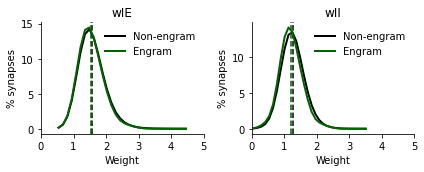

In [19]:
d = np.load("data/fig3/no_assembly_final_weights_and_connectivity_iall_400sec.npz")

total_exc = int(d["total_exc"])

pre_IE, post_IE, w_IE = d["pre_IE"], d["post_IE"], d["w_IE"]
pre_II, post_II, w_II = d["pre_II"], d["post_II"], d["w_II"]

E_eng = np.arange(0, 784)
I_eng = total_exc + np.arange(0, 196)

E_eng_set = set(E_eng.tolist())
I_eng_set = set(I_eng.tolist())

mask_IE_eng = np.isin(pre_IE, I_eng) & np.isin(post_IE, E_eng)
wIE_eng = w_IE[mask_IE_eng]
wIE_non = w_IE[~mask_IE_eng]

mask_II_eng = np.isin(pre_II, I_eng) & np.isin(post_II, I_eng)
wII_eng = w_II[mask_II_eng]
wII_non = w_II[~mask_II_eng]

print("IE engram:", wIE_eng.size, "IE non-engram:", wIE_non.size)
print("II engram:", wII_eng.size, "II non-engram:", wII_non.size)

def gaussian_kernel1d(sigma_bins, radius=4):
    r = int(np.ceil(radius * sigma_bins))
    x = np.arange(-r, r + 1)
    k = np.exp(-(x**2) / (2 * sigma_bins**2))
    k /= k.sum()
    return k

def smooth_curve(y, sigma_bins=1.2):
    return np.convolve(y, gaussian_kernel1d(sigma_bins), mode="same")

def smooth_percent_hist(ax, x, bins, color, alpha=1.0, label=None, sigma_bins=1.2):
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan

    counts, edges = np.histogram(x, bins=bins, density=False)
    centers = 0.5 * (edges[:-1] + edges[1:])

    y = counts * 100.0 / x.size
    y_s = smooth_curve(y, sigma_bins=sigma_bins)

    ax.plot(centers, y_s, color=color, lw=2, alpha=alpha, label=label)

    mu = x.mean()
    ax.axvline(mu, color=color, ls="--", lw=1.5, alpha=alpha)

    ax.set_ylabel("% synapses")
    ax.set_xlabel("Weight")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return mu

def plot_engram_vs_non(ax, eng, non, title, bins=40, sigma_bins=1.2, xlim=None):
    eng = eng[np.isfinite(eng)]
    non = non[np.isfinite(non)]

    all_vals = np.concatenate([eng, non]) if (eng.size and non.size) else (eng if eng.size else non)
    if all_vals.size == 0:
        ax.set_title(title)
        return

    edges = np.histogram_bin_edges(all_vals, bins=bins)

    smooth_percent_hist(ax, non, bins=edges, color="black", alpha=1.0, label="Non-engram", sigma_bins=sigma_bins)
    smooth_percent_hist(ax, eng, bins=edges, color="darkgreen", alpha=1.0, label="Engram", sigma_bins=sigma_bins)

    ax.set_title(title)
    ax.legend(frameon=False)

    if xlim is not None:
        ax.set_xlim(*xlim)

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=False)

plot_engram_vs_non(axes[0], wIE_eng, wIE_non, "wIE", bins=30, sigma_bins=1.2, xlim=(0, 5))
plot_engram_vs_non(axes[1], wII_eng, wII_non, "wII", bins=30, sigma_bins=1.2, xlim=(0, 5))

plt.tight_layout()
plt.show()